In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [2]:
data = pd.read_csv("../../data/processed/Processed_file.csv")

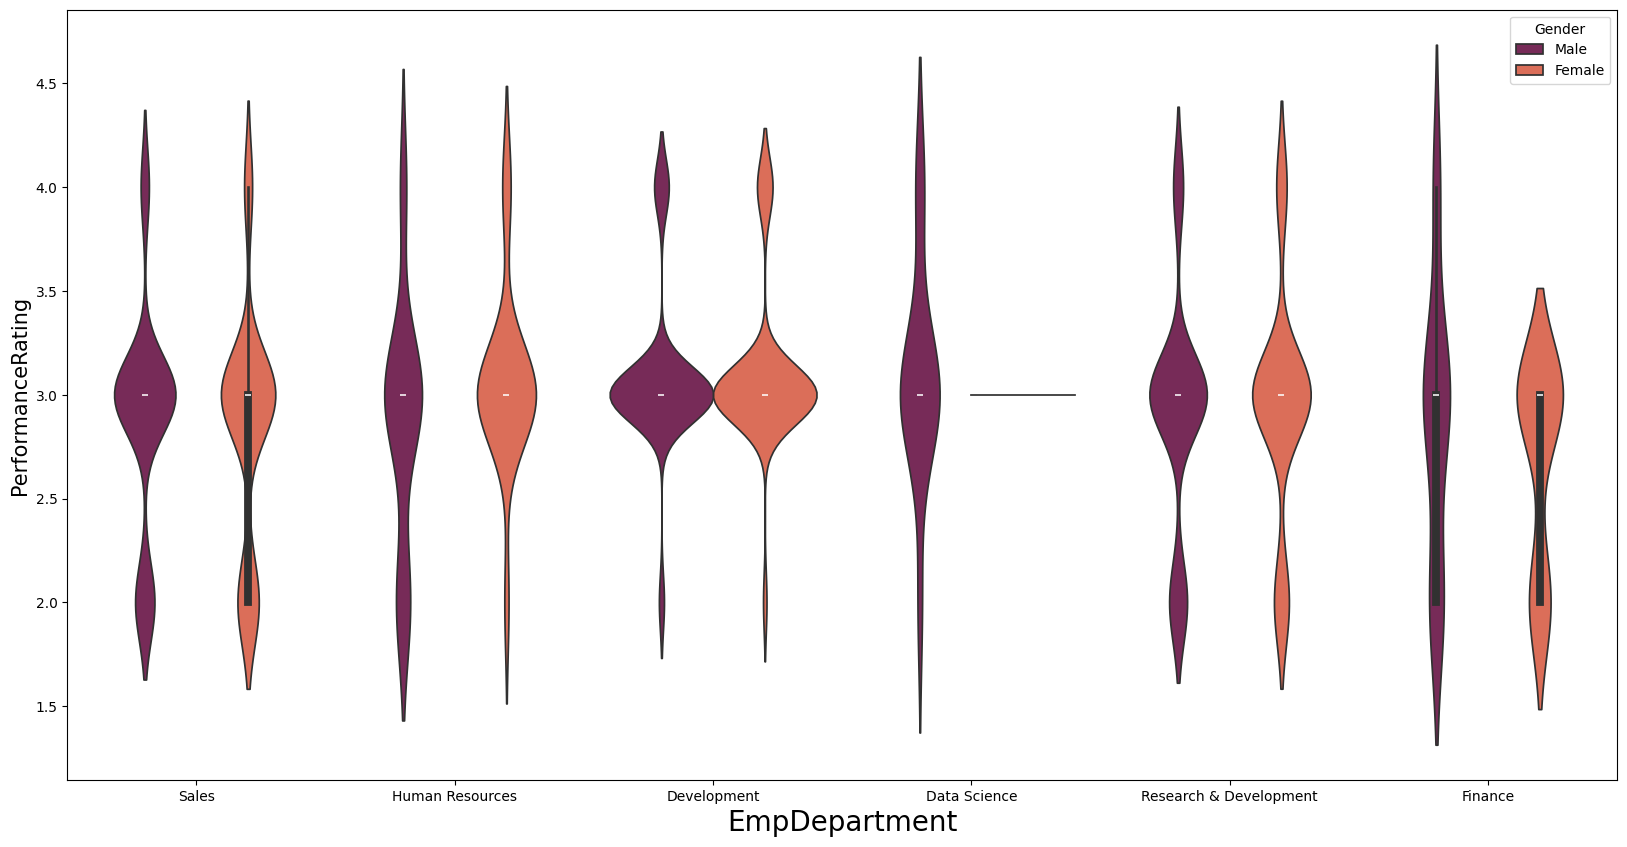

In [3]:

plt.figure(figsize=(20,10),facecolor='white')
sns.violinplot(x='EmpDepartment',y='PerformanceRating',hue=data.Gender,data=data,palette='rocket')

plt.xlabel('EmpDepartment',fontsize=20)
plt.ylabel('PerformanceRating',fontsize=15)
plt.show()

# hue = category of data of colors

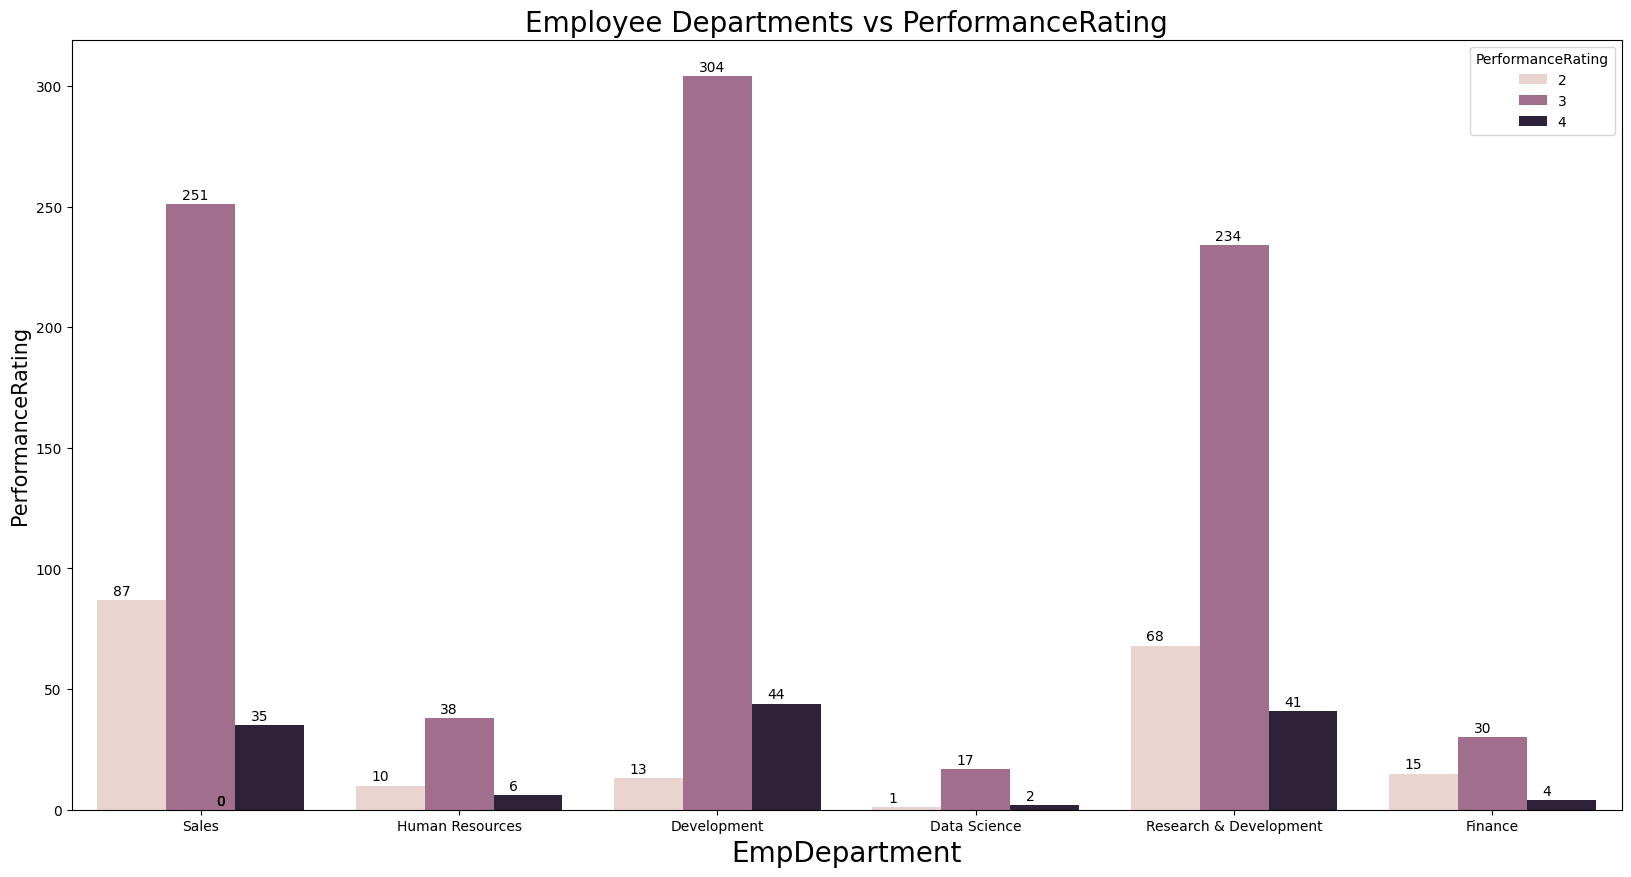

In [4]:

plt.figure(figsize=(20,10),facecolor='white')
ax = sns.countplot(x='EmpDepartment',hue=data.PerformanceRating,data=data)
for i in ax.patches:
    ax.annotate('{:.0f}'.format(i.get_height()), (i.get_x()+0.06, i.get_height()+2))
plt.title('Employee Departments vs PerformanceRating',fontsize=20)
plt.xlabel('EmpDepartment',fontsize=20)
plt.ylabel('PerformanceRating',fontsize=15)
plt.show()

## Observation:
#### From the above graph, we can observe that the Development department shows the highest employee performance ratings compared to other departments.


##### Sales: Most employees in the Sales department fall under performance rating level 3. Male employees show slightly better performance compared to female employees.


##### Human Resources: The majority of employees in the HR department belong to performance level 3. Older employees tend to show lower performance. Female employees in the HR department are performing well compared to male employees.

##### Development: Most employees in the Development department are level 3 performers. Employees from all age groups show similar performance levels. The performance of male and female employees is almost the same.

##### Data Science: The Data Science department has a high number of level 3 performers. It has very few level 2 performers, indicating better overall performance. Male employees show slightly better performance in this department.

##### Research & Development: In the R&D department, employee age does not strongly affect performance. Employees of different age groups are present at all performance levels. Female employees show good performance in this department.

##### Finance: In the Finance department, performance tends to decrease as age increases. Male employees perform better compared to female employees. Experience shows a negative relationship with performance in this department.

In [5]:
# understnad all plot | change theme and make unique code | write insights

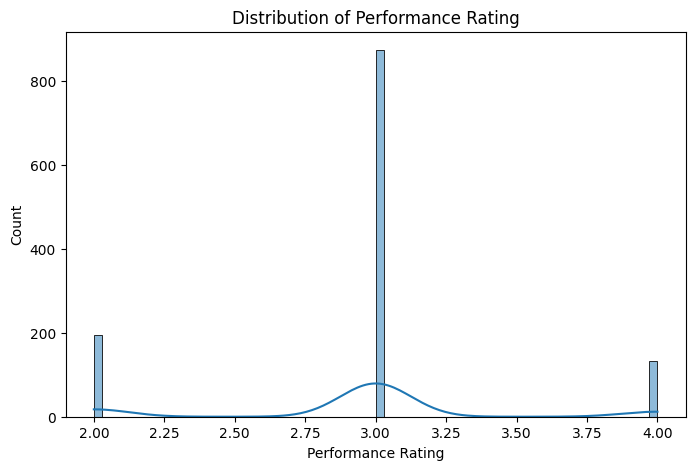

In [6]:

# Visualize the distribution of PerformanceRating
plt.figure(figsize=(8, 5))
sns.histplot(data['PerformanceRating'], kde=True)
plt.title('Distribution of Performance Rating')
plt.xlabel('Performance Rating')
plt.show()

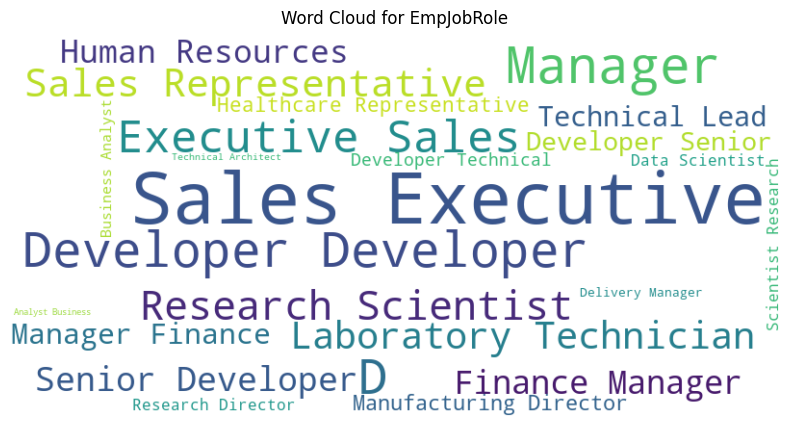

In [7]:

# Word cloud for textual data
textual_data = ' '.join(data['EmpJobRole'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(textual_data)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for EmpJobRole')
plt.show()

Descriptive statistics are used to understand the overall distribution of the PerformanceRating values.

A boxplot is used to compare performance ratings across different departments.

A histogram is used to show how performance ratings are distributed overall.

A word cloud is used to show the frequency of different job roles, where job roles appearing more often are shown in larger and bolder text.

## PERCENT COUNT IN EMPLOYEE DEPARTMENT WITH PERFORMANCE RATING

In [8]:
percent = pd.crosstab(data['PerformanceRating'],data['EmpDepartment'],margins=True,normalize=True)
round(percent.multiply(100),
      2)


# crosstab creates cross table which shows relationship betweeb PerformanceRating and EmpDepartment

EmpDepartment,Data Science,Development,Finance,Human Resources,Research & Development,Sales,All
PerformanceRating,,,,,,,
2,0.08,1.08,1.25,0.83,5.67,7.25,16.17
3,1.42,25.33,2.50,3.17,19.50,20.92,72.83
4,0.17,3.67,0.33,0.50,3.42,2.92,11.00
All,1.67,30.08,4.08,4.50,28.58,31.08,100.00


# Top 3 factors affecting Employee Performance

In [9]:
import seaborn as sns 
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
 
import warnings
# Suppress FutureWarnings
warnings.simplefilter(action='ignore', category=UserWarning)


In [10]:
data.columns

Index(['Unnamed: 0', 'EmpNumber', 'Age', 'Gender', 'EducationBackground',
       'MaritalStatus', 'EmpDepartment', 'EmpJobRole',
       'BusinessTravelFrequency', 'DistanceFromHome', 'EmpEducationLevel',
       'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement',
       'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating'],
      dtype='object')

# Dropping Unwanted Columns

In [11]:
data.drop(['Unnamed: 0', 'EmpNumber'],axis=1,inplace=True)


In [12]:
# separation of X and Y features
X = data.drop(['PerformanceRating'], axis = 1)
y = data['PerformanceRating']

In [13]:
# convert category to dummy variables

X = pd.get_dummies(X, drop_first=True)

In [14]:
# Random Forest Regressor Model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [15]:
# GRADIENT boosting regressor model 
gr_model = GradientBoostingRegressor(random_state=42)
gr_model.fit(X, y )

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [16]:
# Decision Tree Regression Model 
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X , y)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

## feature importance analysis - Random Forest

Top 3 Features Affecting Employee Performance:
EmpLastSalaryHikePercent: 0.24028951805206256
EmpEnvironmentSatisfaction: 0.213835245827278
YearsSinceLastPromotion: 0.19435646950402277


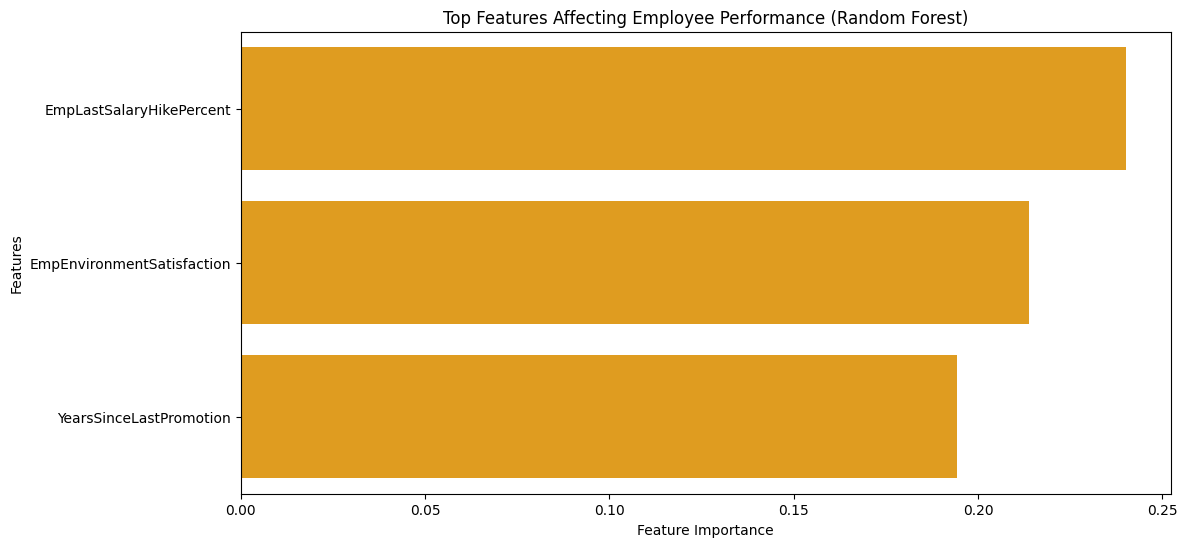

In [17]:
# feature importance analysis - Random Forest
feature_importance = rf_model.feature_importances_
feature_names = X.columns

# sort features based on importance
sorted_indices = feature_importance.argsort()[::-1]

# Top 3 Features 

top_features = 3
print("Top", top_features, "Features Affecting Employee Performance:")
for i in range(top_features):
    print(f"{feature_names[sorted_indices[i]]}: {feature_importance[sorted_indices[i]]}")

# Plot the top features for Random Forest
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importance[sorted_indices[:top_features]], y=feature_names[sorted_indices[:top_features]], color='orange')
plt.title('Top Features Affecting Employee Performance (Random Forest)')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.show()

In [18]:
# 2.Employee last salary hike percent
pd.crosstab(data['EmpLastSalaryHikePercent'],data['PerformanceRating'],margins=True)

PerformanceRating,2,3,4,All
EmpLastSalaryHikePercent,,,,
11,28,140,1,169
12,30,123,2,155
13,27,138,3,168
14,28,140,4,172
15,11,67,4,82
16,12,54,2,68
17,9,55,3,67
18,10,63,0,73
19,10,51,2,63


In [19]:
# 3.Employee Work life balance
pd.crosstab(data['YearsSinceLastPromotion'],data['PerformanceRating'],margins=True)

PerformanceRating,2,3,4,All
YearsSinceLastPromotion,,,,
0,3,405,61,469
1,66,195,36,297
2,37,83,7,127
3,15,25,5,45
4,14,37,2,53
5,10,21,4,35
6,8,12,4,24
7,15,41,6,62
8,5,6,0,11


## Feature importance - Gradient Boosting

Top 3 Features Affecting Employee Performance (Gradient Boosting):
Age: 0.009143767091013512
DistanceFromHome: 0.004237634608037347
EmpEducationLevel: 0.003019487017997454


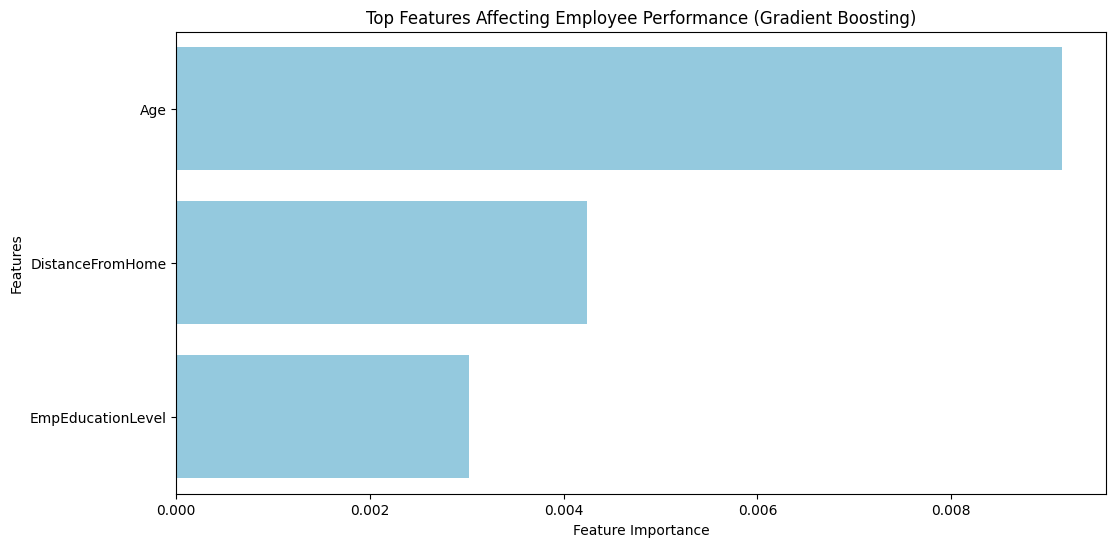

In [20]:
# Feature importance analysis
feature_importances_gb = gr_model.feature_importances_

# Display the top 3 features and their importance scores
top_features_gb = 3
print("Top", top_features_gb, "Features Affecting Employee Performance (Gradient Boosting):")
for i in range(top_features_gb):
    print(f"{feature_names[i]}: {feature_importances_gb[i]}")
    
# Plot the top features for Gradient Boosting
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importances_gb[:top_features_gb], y=feature_names[:top_features_gb], color='skyblue')
plt.title('Top Features Affecting Employee Performance (Gradient Boosting)')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.show()


In [21]:
# 2.Employee last salary hike percent
pd.crosstab(data['EmpLastSalaryHikePercent'],data['PerformanceRating'],margins=True)

PerformanceRating,2,3,4,All
EmpLastSalaryHikePercent,,,,
11,28,140,1,169
12,30,123,2,155
13,27,138,3,168
14,28,140,4,172
15,11,67,4,82
16,12,54,2,68
17,9,55,3,67
18,10,63,0,73
19,10,51,2,63


In [22]:
# 3.Employee Work life balance
pd.crosstab(data['YearsSinceLastPromotion'],data['PerformanceRating'],margins=True)

PerformanceRating,2,3,4,All
YearsSinceLastPromotion,,,,
0,3,405,61,469
1,66,195,36,297
2,37,83,7,127
3,15,25,5,45
4,14,37,2,53
5,10,21,4,35
6,8,12,4,24
7,15,41,6,62
8,5,6,0,11


## Feature importance - Decision Tree

Top 3 Features Affecting Employee Performance (Decision Tree):
Age: 0.026175675823267013
DistanceFromHome: 0.014206362999617783
EmpEducationLevel: 0.007745802561247316


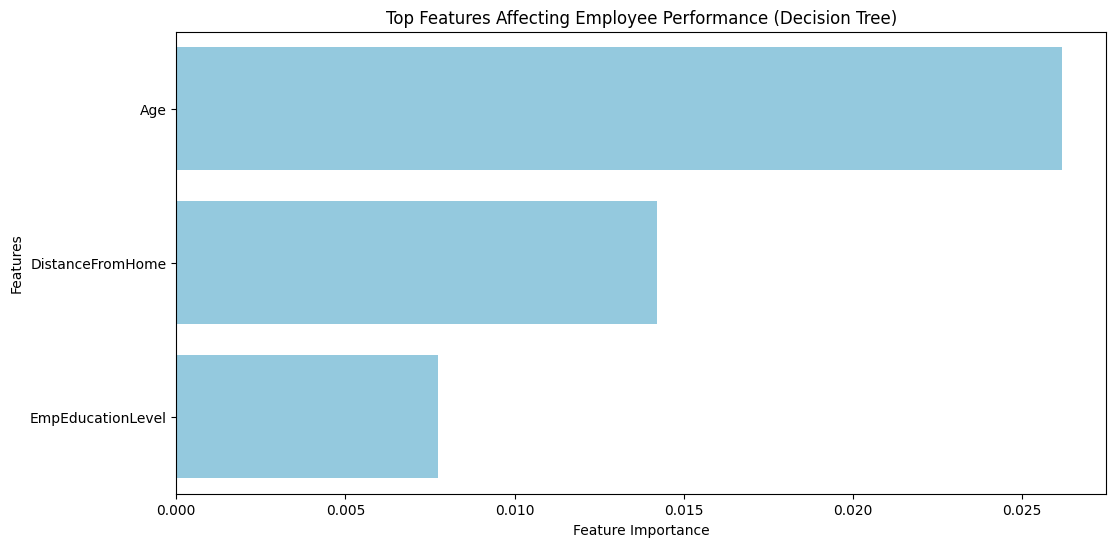

In [23]:
# Feature importance analysis
feature_importances_dt = dt_model.feature_importances_

# Display the top 3 features and their importance scores
top_features_dt = 3
print("Top", top_features_dt, "Features Affecting Employee Performance (Decision Tree):")
for i in range(top_features_dt):
    print(f"{feature_names[i]}: {feature_importances_dt[i]}")
    
# Plot the top features for Decision Tree
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importances_dt[:top_features_dt], y=feature_names[:top_features_dt], color='skyblue')
plt.title('Top Features Affecting Employee Performance (Decision Tree)')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.show()

In [24]:
# 2.Employee last salary hike percent
pd.crosstab(data['EmpLastSalaryHikePercent'],data['PerformanceRating'],margins=True)

PerformanceRating,2,3,4,All
EmpLastSalaryHikePercent,,,,
11,28,140,1,169
12,30,123,2,155
13,27,138,3,168
14,28,140,4,172
15,11,67,4,82
16,12,54,2,68
17,9,55,3,67
18,10,63,0,73
19,10,51,2,63


In [25]:
# 3.Employee Work life balance
pd.crosstab(data['YearsSinceLastPromotion'],data['PerformanceRating'],margins=True)

PerformanceRating,2,3,4,All
YearsSinceLastPromotion,,,,
0,3,405,61,469
1,66,195,36,297
2,37,83,7,127
3,15,25,5,45
4,14,37,2,53
5,10,21,4,35
6,8,12,4,24
7,15,41,6,62
8,5,6,0,11


###  top 3 features affecting employee performance

### Random Forest:
#### EmpLastSalaryHikePercent    
#### EmpEnvironmentSatisfaction  
#### YearsSinceLastPromotion     

### Gradient Boosting:
#### Age 
#### DistanceFromHome  
#### EmpEducationLevel 


### Decision Tree:
#### Age  
#### DistanceFromHome  
#### EmpEducationLevel

## Why I Choose These Models

I selected these models to understand feature importance because they work well with different types of data and are easy to explain. These models also give a good balance between accuracy and simplicity.

## Random Forest
Combination of many trees: Random Forest uses many decision trees together to make better predictions.
Feature importance: It shows which features are important based on how much they help in making correct decisions.
Less overfitting: It is more stable and does not overfit easily, so results are more reliable.

## Gradient Boosting
Step-by-step learning: Gradient Boosting builds trees one after another, and each new tree fixes the mistakes of the previous one.
Feature importance: Features that help reduce errors are given higher importance.
High accuracy: This model usually gives very good prediction results.

## Decision Tree
Easy to understand: Decision Trees are simple and clear. Each decision is made using one feature.
Feature selection: Important features are selected automatically while splitting the data.
Visualization: The tree structure can be easily drawn and understood.

## CHECKING THE DISTRIBUTION OF CONTINUOUS FEATURE

In [26]:
data.select_dtypes(include='int64').head(2)

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
0,32,10,3,4,55,3,2,4,1,12,4,10,2,2,10,7,0,8,3
1,47,14,4,4,42,3,2,1,2,12,4,20,2,3,7,7,1,7,3


In [27]:
data.select_dtypes(include='int64').columns



Index(['Age', 'DistanceFromHome', 'EmpEducationLevel',
       'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement',
       'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'PerformanceRating'],
      dtype='object')

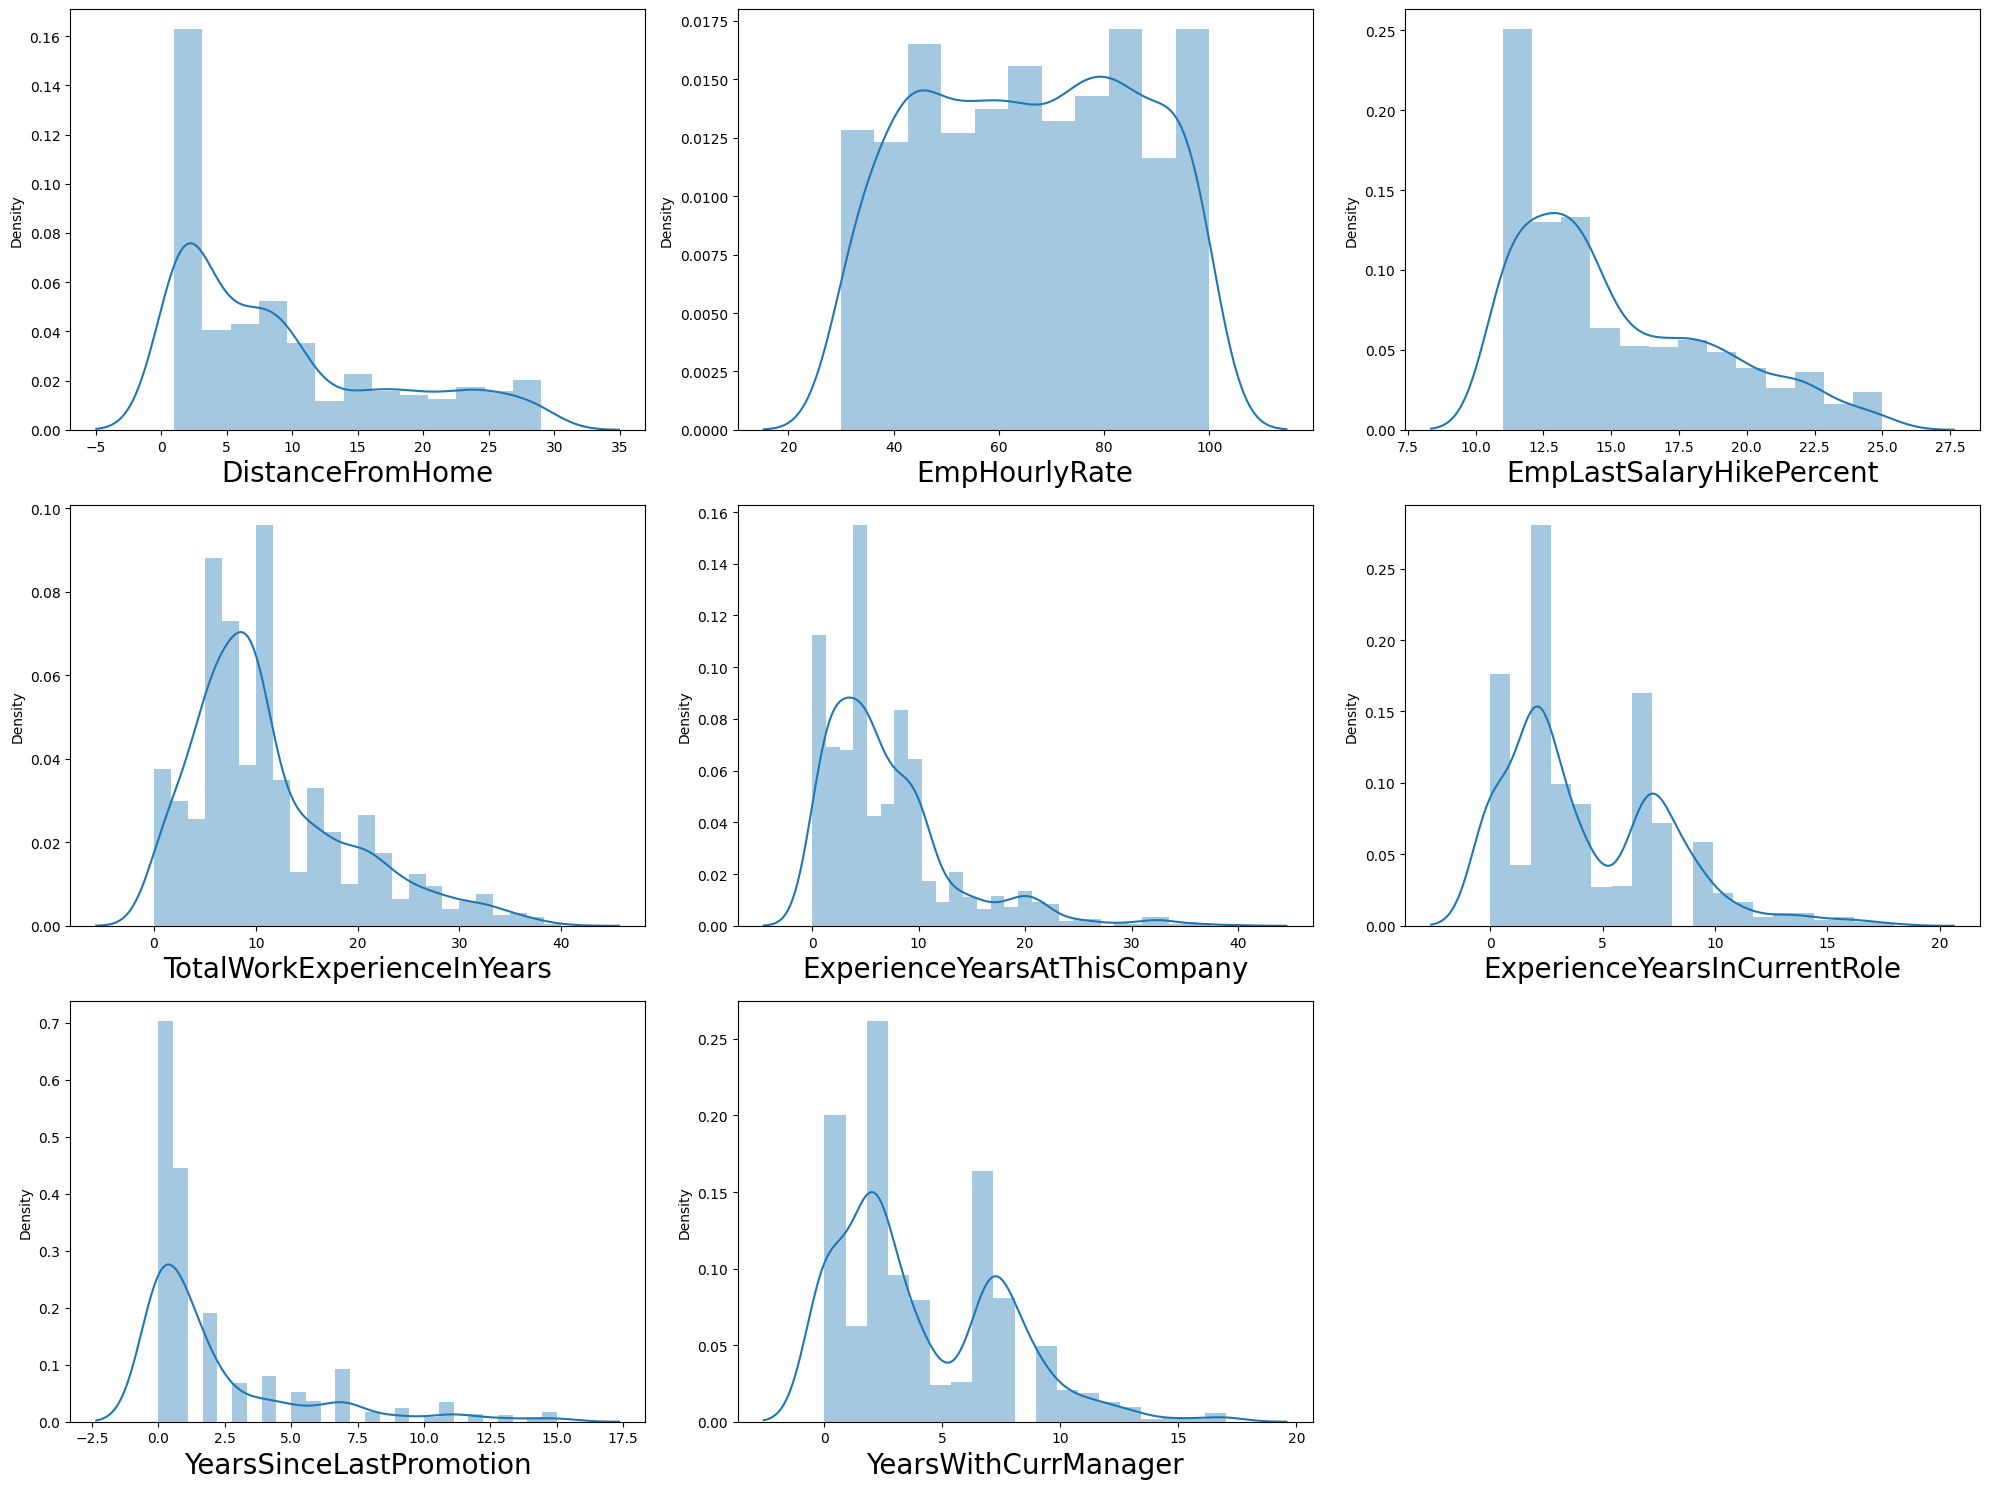

In [28]:
# Extracting True Continueous features
continueous  = data[[
    'DistanceFromHome',
    'EmpHourlyRate',
    'EmpLastSalaryHikePercent',
    'TotalWorkExperienceInYears',
    'ExperienceYearsAtThisCompany',
    'ExperienceYearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]]

plt.figure(figsize=(20,15))
plotno = 1 

for column in continueous: 
    if plotno<=8:   
        plt.subplot(3,3,plotno) 
        sns.distplot(x=continueous[column]) 
        plt.xlabel(column,fontsize=20)  
    plotno+=1
plt.tight_layout()
plt.show()

In [29]:
data.to_csv("../../data/processed/after_visualize.csv")